# MSC Nastran HDF5 results: `.h5`

MSC Nastran writes its results as an HDF5 database when the deck asks for it (`MDLPRM,HDF5,...`, MSC Nastran 2016 and later). Patran reads it instead of the older OP2. The file holds the whole model and every result as compound tables, so meshio++ reads it without a Nastran installation: **`.h5` → `.vtu` / VTKHDF / any meshio++ format**.

Every result *domain* (a subcase, and within it a mode, time step or frequency) is a **step** of the sequence engine. Nodal tables become `point_data`, element tables `cell_data`, and each property id becomes a named region. The two engines (C++ core and Python reference) read the same files identically. `.h5` is read-only: it is what a solver writes.

The files used here are in `tests/python/meshes/nastran_h5/`. They are real MSC Nastran 2020 output from the [pyNastran](https://github.com/SteveDoyle2/pyNastran) repository (BSD 3-Clause). Each one runs one small model, with a card of nearly every element type, through a different solution sequence.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# The reader's warnings (listed in the text below) are read once per process: keep the outputs readable.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

H5 = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes', 'nastran_h5')
TMP = tempfile.mkdtemp()


def path(name):
    return os.path.join(H5, name + '.h5')


def to_grid(mesh, vector=None, scale=0.0, scalars=None):
    '''A PyVista grid of `mesh`'s surfaces and solids, its points moved by `scale * point_data[vector]`.'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line')]
    points = mesh.points + scale * mesh.point_data[vector] if vector else mesh.points
    cells = [mesh.cells[i] for i in keep]
    cell_data = {k: [v[i] for i in keep] for k, v in mesh.cell_data.items() if k in (scalars or ())}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(points, cells, point_data=mesh.point_data, cell_data=cell_data))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460)):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=True, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector((-1.0, -1.4, 0.45), viewup=(0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(1.0)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## The model

`read` returns the first result domain by default. The model comes from `/NASTRAN/INPUT`: the GRID points, then one cell block per element card (a card whose quadratic nodes are all given becomes the quadratic cell type, one with none the linear type). Each block carries the element and property ids as `nastran:eid` and `nastran:pid`, and each property id is a region named after its property card.

The reader warns about what it does not turn into cells (silenced in this notebook by `MESHIOPLUSPLUS_LOG_LEVEL=error`; run without it to see them). Here those are the spring and damper cards (`CELAS*`, `CDAMP*`), which connect scalar points, and one `CTRIA6` and one `CQUAD8` that list only some of their mid-side nodes and are read as linear.

In [2]:
static = mp.read(path('static_elements'))
print(static)
print()
eids = np.concatenate(static.cell_data['nastran:eid'])
print(f"{len(eids)} elements in {len(static.cells)} blocks:", sorted({c.type for c in static.cells}))
print('regions:', [(r.name, r.dim, len(r.entries)) for r in static.regions])
print({k: v.tolist() for k, v in static.field_data.items()})

<meshio++ mesh object>
  Number of points: 40
  Number of cells:
    line: 1
    line: 1
    hexahedron: 1
    vertex: 2
    line: 1
    wedge: 2
    quad: 5
    quad: 1
    quad: 1
    line: 2
    quad: 1
    tetra: 2
    triangle: 8
    triangle: 1
    triangle: 1
    line: 1
    line: 2
    line: 1
  Cell sets: PBAR_1, PBEAM_5, PROD_3, PSHEAR_8, PSHELL_4, PSHELL_6, PSHELL_7, PSHELL_9, PSOLID_2, PTUBE_10, PVISC_50, PVISC_51
  Point data: APPLIED_LOAD, APPLIED_LOAD_ROT, DISPLACEMENT, DISPLACEMENT_ROT, MPC_FORCE, MPC_FORCE_ROT, SPC_FORCE, SPC_FORCE_ROT
  Cell data: ELEMENT_FORCE:AF, ELEMENT_FORCE:BM1, ELEMENT_FORCE:BM2, ELEMENT_FORCE:BMX, ELEMENT_FORCE:BMXY, ELEMENT_FORCE:BMY, ELEMENT_FORCE:F12, ELEMENT_FORCE:F14, ELEMENT_FORCE:F21, ELEMENT_FORCE:F23, ELEMENT_FORCE:F32, ELEMENT_FORCE:F34, ELEMENT_FORCE:F41, ELEMENT_FORCE:F43, ELEMENT_FORCE:KF1, ELEMENT_FORCE:KF2, ELEMENT_FORCE:KF3, ELEMENT_FORCE:KF4, ELEMENT_FORCE:MX, ELEMENT_FORCE:MXY, ELEMENT_FORCE:MY, ELEMENT_FORCE:S12, ELEMENT_FORC

## Static displacements and element stress

A nodal table with `X, Y, Z` and `RX, RY, RZ` members becomes two `(n, 3)` arrays, `DISPLACEMENT` and `DISPLACEMENT_ROT`. Each member of an element table becomes a `cell_data` array named `<group>:<member>`, shared by every card that has it. `STRESS:X` is the normal stress of the solids (their centre value). `STRESS:X1` is the fibre-1 stress of the shells. A cell whose card has no such output is NaN (grey below).

max |u| 0.009543803558518532
STRESS:* arrays: ['STRESS:A', 'STRESS:AS', 'STRESS:FD1', 'STRESS:FD2', 'STRESS:MAX', 'STRESS:MIN', 'STRESS:MS', 'STRESS:MSA', 'STRESS:MSC', 'STRESS:MST', 'STRESS:SD', 'STRESS:T'] ...


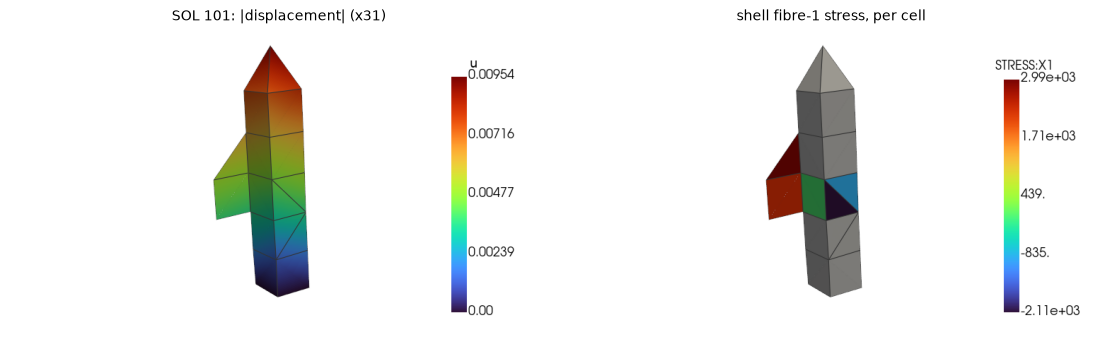

In [3]:
u = static.point_data['DISPLACEMENT']
static.point_data['|u|'] = np.linalg.norm(u, axis=1)
print('max |u|', static.point_data['|u|'].max())
print('STRESS:* arrays:', sorted(k for k in static.cell_data if k.startswith('STRESS:'))[:12], '...')
scale = 0.3 / static.point_data['|u|'].max()
gallery([
    (to_grid(static, 'DISPLACEMENT', scale), '|u|', f'SOL 101: |displacement| (x{scale:.0f})', None),
    (to_grid(static, 'DISPLACEMENT', scale, scalars=['STRESS:X1']), 'STRESS:X1', 'shell fibre-1 stress, per cell', None),
])

## Every solution sequence is a sequence

`read_metadata` lists the steps without reading the results. The value of each step is its domain's `TIME_FREQ_EIGR`, *as written*: the time of a transient run, the frequency of a frequency response, the eigenvalue of a mode. For a real mode that eigenvalue is λ = ω², and for a buckling mode it is the load factor. The domains the result tables use are the steps; a `DOMAINS` row no table uses is not one.

In [4]:
for name in ('static_elements', 'modes_elements', 'freq_elements', 'modes_complex_elements',
             'buckling_solid_shell_bar', 'time_thermal_elements'):
    values = mp.read_metadata(path(name))['time_values']
    last = mp.read(path(name), time_step=-1)
    print(f"{name:26s} steps {len(values):2d}  analysis {last.field_data['nastran:analysis'][0]:5d}  "
          f"values {np.round(values, 3).tolist()[:5]}{' ...' if len(values) > 5 else ''}")

static_elements            steps  1  analysis     1  values [0.0]
modes_elements             steps  3  analysis     2  values [0.0, 0.0, 0.0]
freq_elements              steps  5  analysis     5  values [0.0, 10.0, 20.0, 30.0, 40.0]
modes_complex_elements     steps  4  analysis     9  values [-0.0, -0.0, -0.0, -0.0]
buckling_solid_shell_bar   steps  9  analysis     2  values [0.0, -49358608081.228, -58002089768.551, -379757839000.02, -428462889403.032] ...
time_thermal_elements      steps  9  analysis  1006  values [0.0, 10.0, 20.0, 40.0, 60.0] ...


## Buckling modes

The SOL 105 file holds a static subcase and then four buckling eigenvectors. Tables cover different domains: `DISPLACEMENT` exists only in the static step, `EIGENVECTOR` only in the buckling ones. Each step carries the arrays of the tables that have rows for it.

static step arrays : ['APPLIED_LOAD', 'APPLIED_LOAD_ROT', 'DISPLACEMENT', 'DISPLACEMENT_ROT', 'MPC_FORCE', 'MPC_FORCE_ROT', 'SPC_FORCE', 'SPC_FORCE_ROT']
buckling step arrays: ['EIGENVECTOR', 'EIGENVECTOR_ROT', 'SPC_FORCE', 'SPC_FORCE_ROT']


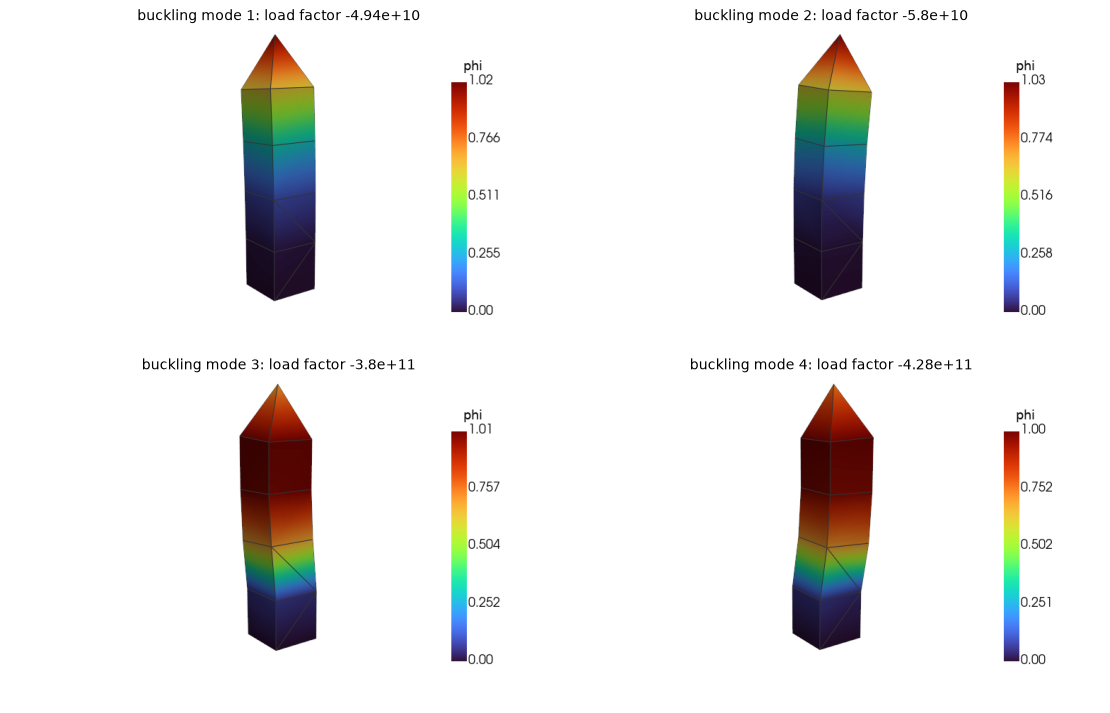

In [5]:
buck = path('buckling_solid_shell_bar')
modes = [mp.read(buck, time_step=s) for s in range(1, 5)]
print('static step arrays :', sorted(mp.read(buck).point_data))
print('buckling step arrays:', sorted(modes[0].point_data))
items = []
for m in modes:
    m.point_data['|phi|'] = np.linalg.norm(m.point_data['EIGENVECTOR'], axis=1)
    s = 0.25 / m.point_data['|phi|'].max()
    items.append((to_grid(m, 'EIGENVECTOR', s), '|phi|',
                  f"buckling mode {m.field_data['nastran:mode'][0]}: load factor {m.field_data['meshio:time'][0]:.3g}", None))
gallery(items)

## Frequency response: real and imaginary parts

A `_CPLX` table (`DISPLACEMENT_CPLX`, members `XR ... RZI`) becomes a pair of arrays per step, `DISPLACEMENT_real` and `DISPLACEMENT_imag`. The SOL 108 deck's load table is zero below 40, so only the last of its five frequencies responds. That is visible straight from the steps, before any plot.

f =    1e-05   max |u| = 0
f =       10   max |u| = 0
f =       20   max |u| = 0
f =       30   max |u| = 0
f =       40   max |u| = 0.08891


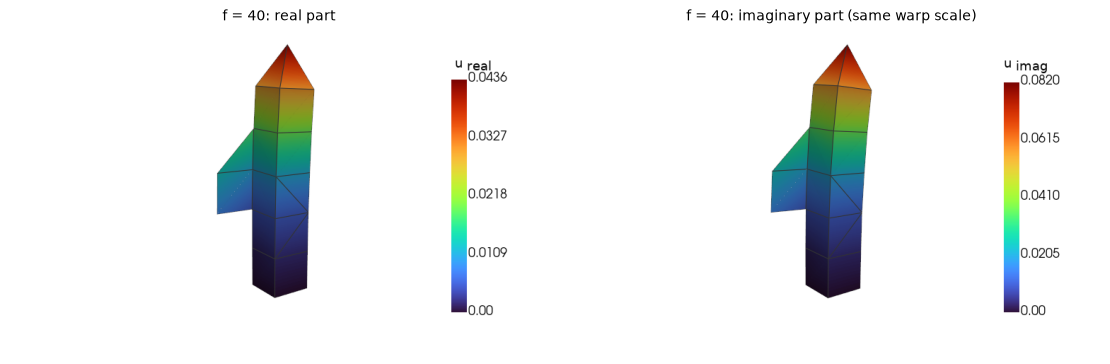

In [6]:
freq = path('freq_elements')
steps = [mp.read(freq, time_step=s) for s in range(len(mp.read_metadata(freq)['time_values']))]
for m in steps:
    amp = np.hypot(m.point_data['DISPLACEMENT_real'], m.point_data['DISPLACEMENT_imag'])
    print(f"f = {m.field_data['meshio:time'][0]:8.5g}   max |u| = {np.nanmax(amp):.4g}")
last = steps[-1]
last.point_data['|u| real'] = np.linalg.norm(last.point_data['DISPLACEMENT_real'], axis=1)
last.point_data['|u| imag'] = np.linalg.norm(last.point_data['DISPLACEMENT_imag'], axis=1)
s = 0.3 / np.nanmax(last.point_data['|u| real'])
gallery([
    (to_grid(last, 'DISPLACEMENT_real', s), '|u| real', 'f = 40: real part', None),
    (to_grid(last, 'DISPLACEMENT_imag', s), '|u| imag', 'f = 40: imaginary part (same warp scale)', None),
])

## A thermal transient

A table with a single `VALUE` member, like `TEMPERATURE`, becomes a scalar array. The SOL 159 file has nine output times, and `read_sequence` walks them.

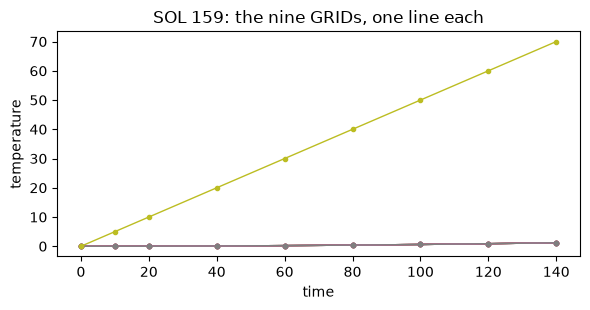

In [7]:
series = list(mp.read_sequence(path('time_thermal_elements')))
t = [time for time, _ in series]
T = np.array([m.point_data['TEMPERATURE'] for _, m in series])
plt.figure(figsize=(6, 3.2))
plt.plot(t, T, '.-', lw=1)
plt.xlabel('time'); plt.ylabel('temperature'); plt.title('SOL 159: the nine GRIDs, one line each')
plt.tight_layout(); plt.show()

## Checked against pyNastran

`pynastran_reference.npz` freezes what pyNastran's own `.h5` reader returns for every translation and rotation table of every domain of these files (`tools/gen_nastran_h5_reference.py` regenerates it). meshio++ reproduces them bit for bit, the SOL 103 eigenvectors included. MSC writes rows for scalar points (SPOINTs) into the same tables; those rows are not points and are dropped.

In [8]:
import h5py  # only to list the GRID ids: the point order is the GRID table's order

ref = np.load(os.path.join(H5, 'pynastran_reference.npz'))
worst, count = 0.0, 0
for key in sorted({k.rsplit('/', 1)[0] for k in ref.files}):
    name, table, domain = key.split('/')
    with h5py.File(path(name)) as fh:
        order = {int(g): i for i, g in enumerate(fh['/NASTRAN/INPUT/NODE/GRID']['ID'][()])}
    n = len(mp.read_metadata(path(name))['time_values'])
    mesh = next(m for m in (mp.read(path(name), time_step=s) for s in range(n))
                if m.field_data['nastran:domain'][0] == int(domain))
    rows = [(r, order[int(i)]) for r, i in enumerate(ref[key + '/ids']) if int(i) in order]
    r = np.array([a for a, _ in rows])
    p = np.array([b for _, b in rows])
    got = np.hstack([mesh.point_data[table][p], mesh.point_data[table + '_ROT'][p]])
    worst = max(worst, np.abs(got - ref[key + '/values'][r]).max())
    count += 1
print(f'{count} tables compared with pyNastran, largest difference {worst}')

38 tables compared with pyNastran, largest difference 0.0


## Steps are sequences

A `{step}` token in the output writes one file per domain. A single-file output for a multi-step input is refused by name rather than truncated to the first step.

In [9]:
series = list(mp.read_sequence(path('modes_elements')))
written = mp.write_sequence(os.path.join(TMP, 'mode_{step}.vtu'), series)
print([os.path.basename(p) for p in written])
back = mp.read(written[2])
print('mode', back.field_data['nastran:mode'][0], '| EIGENVECTOR', back.point_data['EIGENVECTOR'].shape)
try:
    mp.write_sequence(os.path.join(TMP, 'modes.vtu'), series)
except Exception as exc:
    print(type(exc).__name__ + ':', exc)

['mode_0000.vtu', 'mode_0001.vtu', 'mode_0002.vtu']
mode 3 | EIGENVECTOR (40, 3)
WriteError: meshio++: sequence: format 'vtu' cannot hold a multi-step series (only 'xdmf' / 'gid' / 'usd' / 'vtkhdf' / 'pvd' can); write one file per step with an output path containing '{step}' instead


## Onward: to ParaView

The same results are one command away from any other meshio++ format, from either CLI:

```sh
meshioplusplus convert job.h5 'step_{step}.vtu'         # one file per result domain
meshioplusplus convert --time-step=-1 job.h5 last.vtu
meshioplusplus info job.h5
```

The limits are spelled out in the [MSC Nastran HDF5 format page](../../doc/formats/nastran_h5.md). Local coordinate systems (`CP`/`CD`) are recorded but not applied. Per-ply and per-station values beyond the first entry are not read. Other vendors' HDF5 schemas are refused rather than misread.